# Traditional Programming Baseline — Findings

A rule-based classifier was created using manually selected lexical and URL-based indicators.

The classifier assigns a suspicion score based on predefined patterns and predicts spam when the score reaches a specified threshold.

## Why this is Traditional Programming

The system does not learn the classification rules from the dataset. The developer explicitly defines:

- suspicious keywords
- urgency indicators
- financial indicators
- URL detection
- classification threshold

## Evaluation

The classifier was evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

## Limitations

The rule-based approach may fail when:

- a spam message uses unfamiliar wording
- a legitimate message contains suspicious keywords
- attackers change their language
- context matters more than individual words
- messages contain patterns that were not anticipated when the rules were written

## Next Step

The next experiment will use machine learning to learn patterns from the training data rather than relying entirely on manually defined rules.

In [1]:
import pandas as pd
import re

In [2]:
file_path = "../data/processed/sms_spam_clean.csv"

df = pd.read_csv(file_path)

df.head()

,label,message,message_length,label_encoded,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",111,0,"go until jurong point, crazy.. available only ..."
1,ham,Ok lar... Joking wif u oni...,29,0,ok lar... joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,1,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,49,0,u dun say so early hor... u c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,0,"nah i don't think he goes to usf, he lives aro..."


In [3]:
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset shape: (5169, 5)
Columns: ['label', 'message', 'message_length', 'label_encoded', 'message_clean']


In [4]:
suspicious_keywords = [
    "free",
    "winner",
    "won",
    "prize",
    "claim",
    "urgent",
    "congratulations",
    "bonus",
    "offer",
    "cash",
    "reward"
]

urgency_keywords = [
    "urgent",
    "immediately",
    "now",
    "asap",
    "act now",
    "limited time"
]

financial_keywords = [
    "bank",
    "account",
    "payment",
    "credit",
    "debit",
    "money",
    "transfer"
]

In [5]:
def rule_based_classifier(message):
    text = str(message).lower()

    score = 0

    for keyword in suspicious_keywords:
        if keyword in text:
            score += 1

    for keyword in urgency_keywords:
        if keyword in text:
            score += 1

    for keyword in financial_keywords:
        if keyword in text:
            score += 1

    if re.search(r"https?://|www\.", text):
        score += 1

    if score >= 2:
        return 1

    return 0

In [6]:
test_messages = [
    "Hello, are we still meeting today?",
    "Congratulations! You won a free cash prize. Claim now!",
    "Your bank account needs urgent verification.",
    "Can you send me the assignment?"
]

for message in test_messages:
    prediction = rule_based_classifier(message)

    print("Message:", message)
    print("Prediction:", prediction)
    print()

Message: Hello, are we still meeting today?
Prediction: 0

Message: Congratulations! You won a free cash prize. Claim now!
Prediction: 1

Message: Your bank account needs urgent verification.
Prediction: 1

Message: Can you send me the assignment?
Prediction: 0



In [7]:
def prediction_label(prediction):
    if prediction == 1:
        return "SPAM"
    return "LEGITIMATE"

In [8]:
for message in test_messages:
    prediction = rule_based_classifier(message)

    print("Message:", message)
    print("Prediction:", prediction_label(prediction))
    print()

Message: Hello, are we still meeting today?
Prediction: LEGITIMATE

Message: Congratulations! You won a free cash prize. Claim now!
Prediction: SPAM

Message: Your bank account needs urgent verification.
Prediction: SPAM

Message: Can you send me the assignment?
Prediction: LEGITIMATE



In [9]:
df["rule_prediction"] = df["message_clean"].apply(
    rule_based_classifier
)

In [10]:
df[["label", "message", "rule_prediction"]].head(10)

,label,message,rule_prediction
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,0
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1
6,ham,Even my brother is not like to speak with me. ...,0
7,ham,As per your request 'Melle Melle (Oru Minnamin...,0
8,spam,WINNER!! As a valued network customer you have...,1
9,spam,Had your mobile 11 months or more? U R entitle...,0


In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    df["label_encoded"],
    df["rule_prediction"]
)

print(f"Rule-based accuracy: {accuracy:.4f}")

Rule-based accuracy: 0.9120


In [12]:
from sklearn.metrics import classification_report

print(
    classification_report(
        df["label_encoded"],
        df["rule_prediction"],
        target_names=["LEGITIMATE", "SPAM"]
    )
)

              precision    recall  f1-score   support

  LEGITIMATE       0.92      0.99      0.95      4516
        SPAM       0.82      0.39      0.53       653

    accuracy                           0.91      5169
   macro avg       0.87      0.69      0.74      5169
weighted avg       0.91      0.91      0.90      5169



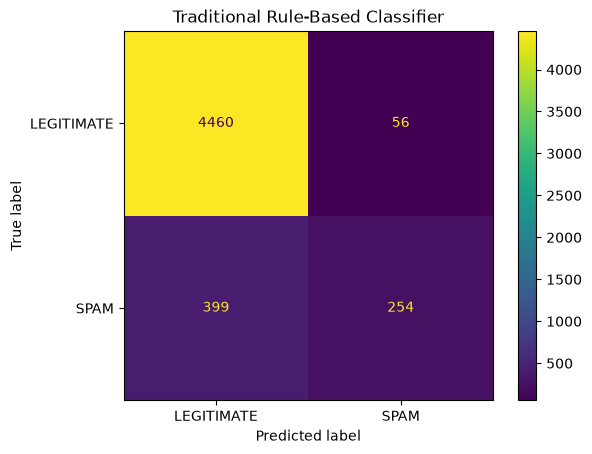

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    df["label_encoded"],
    df["rule_prediction"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["LEGITIMATE", "SPAM"]
)

disp.plot()
plt.title("Traditional Rule-Based Classifier")
plt.show()

In [15]:
errors = df[
    df["label_encoded"] != df["rule_prediction"]
]

print("Number of classification errors:", len(errors))

errors[["label", "message", "rule_prediction"]].head(20)

Number of classification errors: 455


,label,message,rule_prediction
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,0
9,spam,Had your mobile 11 months or more? U R entitle...,0
11,spam,"SIX chances to win CASH! From 100 to 20,000 po...",0
19,spam,England v Macedonia - dont miss the goals/team...,0
34,spam,Thanks for your subscription to Ringtone UK yo...,0
54,spam,SMS. ac Sptv: The New Jersey Devils and the De...,0
68,spam,"Did you hear about the new ""Divorce Barbie""? I...",0
95,spam,Your free ringtone is waiting to be collected....,0
122,spam,Todays Voda numbers ending 7548 are selected t...,0
126,ham,"Just so that you know,yetunde hasn't sent mone...",1
